In [47]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
import io

Saving NYPD_Arrest_YTD_Data.csv to NYPD_Arrest_YTD_Data (3).csv


In [48]:
#Load data set
df_nypd = pd.read_csv("NYPD_Arrest_YTD_Data.csv")

In [49]:
#Display first 5 rows
df_nypd.head(5)

,ARREST_KEY,ARREST_DATE,PD_CD,PD_DESC,KY_CD,OFNS_DESC,LAW_CODE,LAW_CAT_CD,ARREST_BORO,ARREST_PRECINCT,JURISDICTION_CODE,AGE_GROUP,PERP_SEX,PERP_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Location
0,299201470,01/10/2025,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,Q,110,0,25-44,F,WHITE,1017105,210917,40.745543,-73.881427,POINT (-73.881427 40.745543)
1,299351927,01/13/2025,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,S,120,0,25-44,M,BLACK,962808,174275,40.645005,-74.077265,POINT (-74.077265 40.645005)
2,299366743,01/13/2025,157,RAPE 1,104.0,RAPE,PL 130351A,F,B,46,0,25-44,M,BLACK HISPANIC,1011755,250279,40.853598,-73.900577,POINT (-73.9005768807295 40.8535983673823)
3,300990163,02/12/2025,153,RAPE 3,104.0,RAPE,PL 1302504,F,K,77,0,(null),(null),BLACK,1003509,185018,40.674496,-73.930571,POINT (-73.9305713255961 40.6744956865259)
4,301010124,02/12/2025,157,RAPE 1,104.0,RAPE,PL 130353A,F,K,77,0,25-44,M,BLACK,1003509,185018,40.674496,-73.930571,POINT (-73.9305713255961 40.6744956865259)


In [50]:
#Display all column names
df_nypd.columns

Index(['ARREST_KEY', 'ARREST_DATE', 'PD_CD', 'PD_DESC', 'KY_CD', 'OFNS_DESC',
       'LAW_CODE', 'LAW_CAT_CD', 'ARREST_BORO', 'ARREST_PRECINCT',
       'JURISDICTION_CODE', 'AGE_GROUP', 'PERP_SEX', 'PERP_RACE', 'X_COORD_CD',
       'Y_COORD_CD', 'Latitude', 'Longitude', 'Location'],
      dtype='object')

In [51]:
#Dispaly all columns data types
df_nypd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278953 entries, 0 to 278952
Data columns (total 19 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   ARREST_KEY         278953 non-null  int64  
 1   ARREST_DATE        278953 non-null  object 
 2   PD_CD              278953 non-null  int64  
 3   PD_DESC            278953 non-null  object 
 4   KY_CD              278930 non-null  float64
 5   OFNS_DESC          278953 non-null  object 
 6   LAW_CODE           278953 non-null  object 
 7   LAW_CAT_CD         277479 non-null  object 
 8   ARREST_BORO        278953 non-null  object 
 9   ARREST_PRECINCT    278953 non-null  int64  
 10  JURISDICTION_CODE  278953 non-null  int64  
 11  AGE_GROUP          278953 non-null  object 
 12  PERP_SEX           278953 non-null  object 
 13  PERP_RACE          278953 non-null  object 
 14  X_COORD_CD         278953 non-null  int64  
 15  Y_COORD_CD         278953 non-null  int64  
 16  La

In [57]:
#Filter Data - Compare arrests between Manhattan(M) vs. Queens(K) [Checks each row in the 'ARREST_BORO' column to see if its value is present in the list]

df_filter = df_nypd[df_nypd['ARREST_BORO'].isin(['M', 'Q'])]

In [58]:
#Count total arrest at Queens(Q) and Manhattan (M)

df_filter['ARREST_BORO'].value_counts()

,count
ARREST_BORO,
M,66448
Q,58083


In [54]:
#Count total arrest records by AGE_GROUP

df_filter['AGE_GROUP'].value_counts()

,count
AGE_GROUP,
(null),60445
25-44,37787
45-64,14599
18-24,8470
<18,1836
65+,1394


In [55]:
#Count total records by PREP_RACE

df_filter ['PERP_RACE'].value_counts()

,count
PERP_RACE,
BLACK,54621
WHITE HISPANIC,33890
WHITE,13432
BLACK HISPANIC,11287
ASIAN / PACIFIC ISLANDER,10318
AMERICAN INDIAN/ALASKAN NATIVE,557
UNKNOWN,426


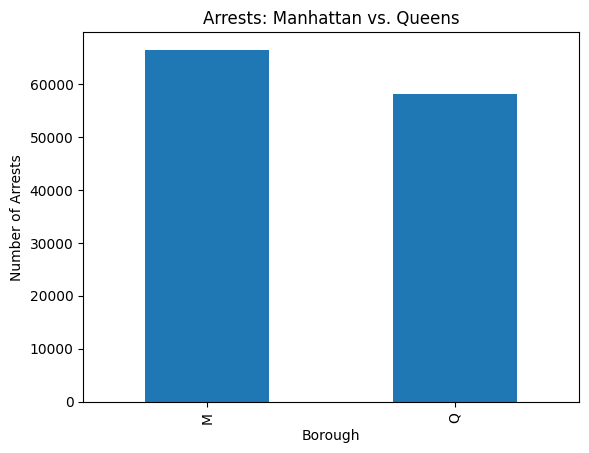

In [56]:
import matplotlib.pyplot as plt

#Compare Arrests: Manhattan vs. Queens

boro_counts = df_filter['ARREST_BORO'].value_counts()

boro_counts.plot(kind='bar')
plt.title("Arrests: Manhattan vs. Queens")
plt.xlabel("Borough")
plt.ylabel("Number of Arrests")
plt.show()

#Conclusion : The results show Manhattan has a higher number of arrests than Queens.